# Stock market trend prediction

### This project focuses on analyzing Tesla’s stock price time series to detect and forecast market trends (bullish, bearish, or neutral). It begins with traditional statistical and technical indicator methods, then progressively integrates advanced machine learning and deep learning algorithms to improve the accuracy and responsiveness of trend detection. The outcome is a comparative study and prototype capable of automatically identifying the current trend and predicting potential reversals.

By Thomas Jin, Thibault Gauthé, Yijia Zhang

In [168]:
import pandas as pd
import ta
import seaborn as sns
import numpy as np
from math import ceil
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight



# Data Collection

In [134]:
data = pd.read_csv('Tesla_Stock_Data.csv')
data.head()

,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


### Data Overview

In [135]:
print("Shape:", data.shape)

Shape: (3843, 6)


In [136]:
print("\nColumns and dtypes:\n", data.dtypes)


Columns and dtypes:
 Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [137]:
print("\nFirst 5 rows:")
print(data.head())
print("\nLast 5 rows:")
print(data.tail())


First 5 rows:
         Date     Close      High       Low      Open     Volume
0  2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1  2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2  2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3  2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4  2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500

Last 5 rows:
            Date       Close        High         Low        Open     Volume
3838  2025-10-01  459.459991  462.290009  440.750000  443.799988   98122300
3839  2025-10-02  436.000000  470.750000  435.570007  470.540009  137009000
3840  2025-10-03  429.829987  446.769989  416.579987  443.290009  133188200
3841  2025-10-06  453.250000  453.549988  436.690002  440.750000   85324900
3842  2025-10-07  433.089996  452.679993  432.450012  447.820007  101798300


In [138]:
print("\nMissing values (count):\n", data.isnull().sum())


Missing values (count):
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [139]:
data.duplicated().sum()

0

In [140]:
print("\nDescriptive statistics:\n", data.describe().T)


Descriptive statistics:
          count          mean           std           min           25%  \
Close   3843.0  9.388797e+01  1.186940e+02  1.053333e+00  1.269167e+01   
High    3843.0  9.599240e+01  1.214350e+02  1.108667e+00  1.288867e+01   
Low     3843.0  9.168992e+01  1.158776e+02  9.986670e-01  1.240900e+01   
Open    3843.0  9.391116e+01  1.187844e+02  1.076000e+00  1.261367e+01   
Volume  3843.0  9.699445e+07  7.621392e+07  1.777500e+06  5.086650e+07   

                 50%           75%           max  
Close   1.945400e+01  2.007400e+02  4.798600e+02  
High    1.988800e+01  2.045917e+02  4.885400e+02  
Low     1.911600e+01  1.952133e+02  4.575100e+02  
Open    1.948333e+01  2.004667e+02  4.759000e+02  
Volume  8.339850e+07  1.222820e+08  9.140820e+08  


We can see that the brut dataset has no missing values nor duplicates so at this point we don't have nothing to clean

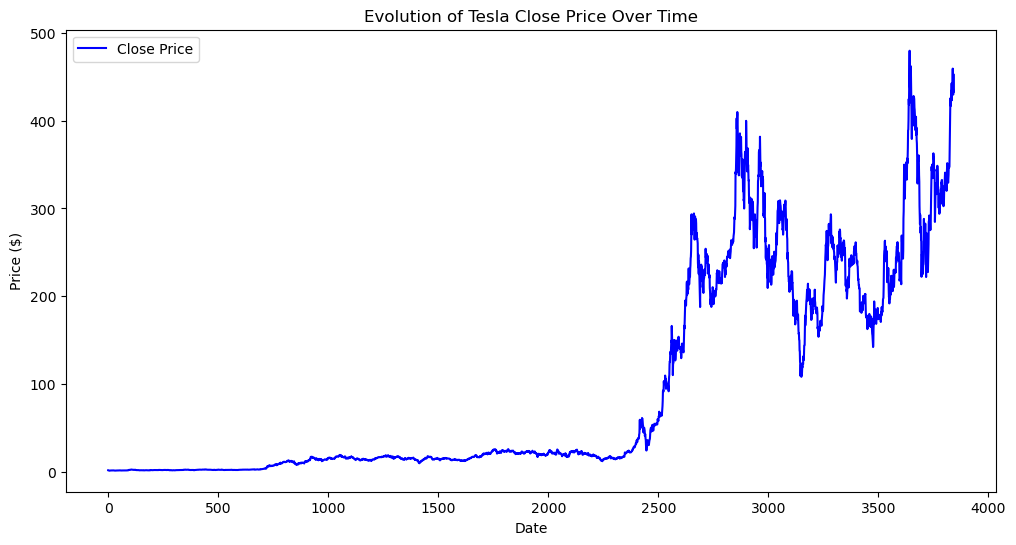

In [141]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Close Price", color="blue")
plt.title("Evolution of Tesla Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

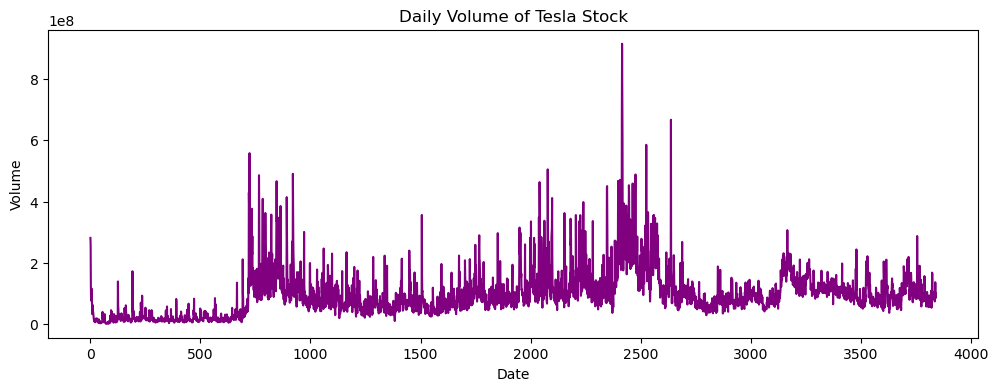

In [142]:
plt.figure(figsize=(12,4))
plt.plot(data["Volume"], color="purple")
plt.title("Daily Volume of Tesla Stock")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Data Preparation for EDA

### Coherence verification

In [143]:
data = data.sort_index() # Sort the data by index to ensure chronological order
print(data.index.is_monotonic_increasing) # Verify that the index is sorted in increasing order (should return True)

True


In [144]:
# Check for rows where High is less than Low

invalid = data[data["High"] < data["Low"]]
print(invalid.head())

Empty DataFrame
Columns: [Date, Close, High, Low, Open, Volume]
Index: []


In [145]:
# Check for invalid values in Volume column

print((data["Volume"] <= 0).sum())

0


In [146]:
# Check for extreme daily returns (e.g., greater than 50% in absolute value)
data["Return_1d"] = data["Close"].pct_change()
print((data["Return_1d"].abs() > 0.5).sum())

0


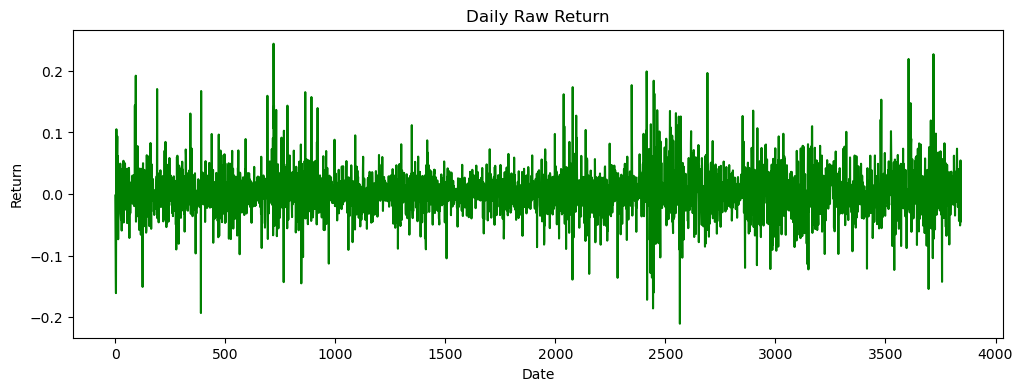

In [147]:
plt.figure(figsize=(12,4))
plt.plot(data["Return_1d"], color="green")
plt.title("Daily Raw Return")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

### Analysis of Daily Returns

The daily return plot shows the volatility and price fluctuations of Tesla stock over time. We observe several key patterns:

- **High volatility periods**: There are notable spikes in both positive and negative returns, indicating periods of significant market movements
- **Volatility clustering**: Periods of high volatility tend to cluster together, which is typical for stock market data
- **Extreme events**: Some returns exceed ±20%, suggesting major announcements or market events affecting Tesla's stock price
- **Recent patterns**: The more recent data (right side of the plot) shows continued volatility, reflecting Tesla's dynamic market behavior

This return series will be essential for our trend prediction models, as it captures the momentum and volatility characteristics that often precede trend changes.

### Feature engineering

In [148]:
# Let's convert the 'Date' column to datetime format and set it as the index
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')
data = data.sort_values('Date')
data = data.set_index('Date')

In [149]:
# Here we will create new features that could help our model to predict trends better

# moving averages : the meaning of the closing prices over a specific period
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()

# rolling volatility : it measures the price fluctuations over a specific period
data["Volatility_20d"] = data["Return_1d"].rolling(20).std()

# Relative Strength Index (RSI) : it indicates whether a stock is overbought or oversold
data["RSI_14"] = ta.momentum.rsi(data["Close"], window=14)

In [150]:
# Now, we will create the target variable 'Trend' by comparing the closing price of the next day with the current day

data["Trend"] = (data["Close"].shift(-1) > data["Close"]).astype(int) # 1 if bullish day, 0 if bearish day

In [151]:
print(data.head())

               Close      High       Low      Open     Volume  Return_1d  \
Date                                                                       
2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500        NaN   
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500  -0.002511   
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000  -0.078473   
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000  -0.125683   
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500  -0.160937   

            MA50  MA200  Volatility_20d  RSI_14  Trend  
Date                                                    
2010-06-29   NaN    NaN             NaN     NaN      0  
2010-06-30   NaN    NaN             NaN     NaN      0  
2010-07-01   NaN    NaN             NaN     NaN      0  
2010-07-02   NaN    NaN             NaN     NaN      0  
2010-07-06   NaN    NaN             NaN     NaN      0  


We can see here that some value are missing because in order to get those you have to get the values of the 50/200 previous one

### Final cleaning step

In [152]:
data = data.dropna()
print(data.isnull().sum())

Close             0
High              0
Low               0
Open              0
Volume            0
Return_1d         0
MA50              0
MA200             0
Volatility_20d    0
RSI_14            0
Trend             0
dtype: int64


In [153]:
print(data.head())
print(data.tail())

               Close      High       Low      Open    Volume  Return_1d  \
Date                                                                      
2011-04-12  1.643333  1.680667  1.620000  1.672000  20361000  -0.024535   
2011-04-13  1.662000  1.712667  1.654000  1.675333  18172500   0.011359   
2011-04-14  1.676000  1.685333  1.613333  1.658000  14751000   0.008424   
2011-04-15  1.705333  1.745333  1.694000  1.710000  14152500   0.017502   
2011-04-18  1.668667  1.708000  1.624000  1.675333  15508500  -0.021501   

                MA50     MA200  Volatility_20d     RSI_14  Trend  
Date                                                              
2011-04-12  1.597293  1.581757        0.045385  49.263004      1  
2011-04-13  1.598653  1.582103        0.045344  50.769372      1  
2011-04-14  1.600253  1.582540        0.045328  51.922269      1  
2011-04-15  1.602853  1.583747        0.045404  54.335217      0  
2011-04-18  1.604947  1.585690        0.045693  50.896591      1  
     

# EDA Phase

# Data preparation for modeling

### Train Test Split

Before normalizing for base models like logistic regression, we will split the dataset into two parts: the training set and the test set. We will not shuffle the data because we are working with time series data, where the chronological order must be preserved to avoid data leakage and ensure realistic model evaluation.

In [154]:
features = ["Return_1d", "MA50", "MA200", "Volatility_20d", "RSI_14"]
target = "Trend"

In [155]:
# in order to avoid data leakage, we will split the data into training and testing sets based on a specific date
# and not by using the train_test_split function because it shuffles the data by default 
# We will use data up to 2022-12-31 for training and data from 2023-01-01 for testing (80-20 split)
train = data.loc[: "2022-12-31"]
test = data.loc["2023-01-01":]

In [157]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [161]:
# Verify that there is no overlap between training and testing sets
print(X_train.shape, X_test.shape)
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

assert train.index.max() < test.index.min()

(2951, 5) (693, 5)
2011-04-12 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2025-10-07 00:00:00


The 80-20 temporal split (training on data up to 2022-12-31 and testing from 2023-01-01 onward) is strategically chosen to replicate a realistic trading scenario. The model learns from Tesla's long historical patterns spanning over a decade, then faces the challenge of predicting trends in the highly volatile 2023-2025 period characterized by post-COVID market dynamics, interest rate changes, and increased uncertainty. This approach provides the most rigorous test of model robustness, as it must generalize to recent market conditions that differ significantly from the training period, mimicking how a production model would perform when deployed in live trading environments.

### Normalization and scaling

In [164]:
scaler = StandardScaler()

# only on the train because we want to avoid data leakage
scaler.fit(X_train)

# transformation of train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [165]:
# Converting the scaled arrays back to DataFrames for easier handling

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

In [167]:
print(X_train_scaled.head())
print(X_test_scaled.head())

            Return_1d      MA50     MA200  Volatility_20d    RSI_14
Date                                                               
2011-04-12  -0.749475 -0.620452 -0.596514        0.928121 -0.310778
2011-04-13   0.261188 -0.620438 -0.596511        0.925145 -0.194671
2011-04-14   0.178532 -0.620421 -0.596506        0.923968 -0.105808
2011-04-15   0.434140 -0.620394 -0.596492        0.929490  0.080176
2011-04-18  -0.664031 -0.620373 -0.596471        0.950563 -0.184865
            Return_1d      MA50     MA200  Volatility_20d    RSI_14
Date                                                               
2023-01-03  -3.505619  1.209920  2.187974        1.356800 -2.191798
2023-01-04   1.384335  1.188979  2.177479        1.513780 -1.834255
2023-01-05  -0.876282  1.168016  2.166506        1.513115 -1.920863
2023-01-06   0.635438  1.145297  2.154331        1.584047 -1.740295
2023-01-09   1.612406  1.123511  2.142435        1.783803 -1.313370


### Class distribution

In [174]:
# Check class distribution in the full dataset
print("Full dataset class distribution:")
print(data["Trend"].value_counts())
print("\nPercentage:")
print(data["Trend"].value_counts(normalize=True) * 100)

Full dataset class distribution:
Trend
1    1885
0    1759
Name: count, dtype: int64

Percentage:
Trend
1    51.728869
0    48.271131
Name: proportion, dtype: float64


In [176]:
print("Training set class distribution:")
print(y_train.value_counts())
print("\nPercentage:")
print(y_train.value_counts(normalize=True) * 100)

Training set class distribution:
Trend
1    1525
0    1426
Name: count, dtype: int64

Percentage:
Trend
1    51.677397
0    48.322603
Name: proportion, dtype: float64


In [177]:
print("Test set class distribution:")
print(y_test.value_counts())
print("\nPercentage:")
print(y_test.value_counts(normalize=True) * 100)

Test set class distribution:
Trend
1    360
0    333
Name: count, dtype: int64

Percentage:
Trend
1    51.948052
0    48.051948
Name: proportion, dtype: float64


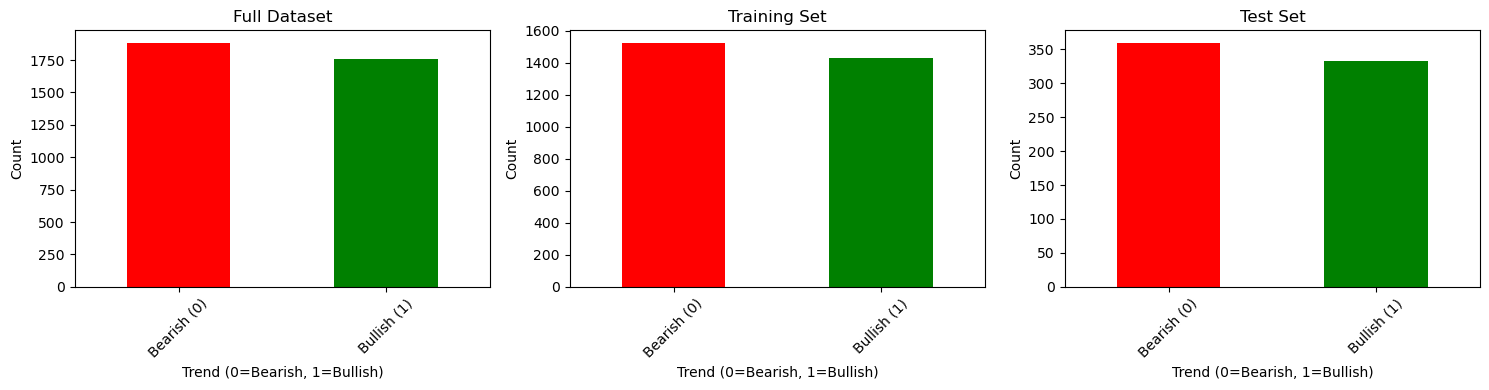

In [179]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data["Trend"].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Full Dataset')
axes[0].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

y_train.value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Training Set')
axes[1].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

y_test.value_counts().plot(kind='bar', ax=axes[2], color=['red', 'green'])
axes[2].set_title('Test Set')
axes[2].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

plt.tight_layout()
plt.show()

The class distribution analysis reveals that all datasets (full, training, and test sets) maintain a relatively balanced distribution between bearish (0) and bullish (1) trends, with approximately 48-49% bearish days and 51-52% bullish days. This near-equal distribution indicates that no class imbalance correction methods (such as SMOTE, class weights, or resampling techniques) are necessary, as the classes are naturally balanced. This balanced distribution allows our models to learn effectively from both classes without bias, ensuring fair and reliable trend predictions.

# Modelisation - Level 1 

# Modelisation - Level 2